In [116]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [117]:
rng = np.random.default_rng()

In [129]:
x = np.arange(0,1.01, .01)
m = 3
b = 5
y = m*x + b + random.randint(0,1)

In [130]:
def my_lstq(x, y):
    n = len(x)
    xsum = np.sum(x)
    ysum = np.sum(y)
    xysum = np.sum(x*y)
    xxsum = np.sum(x**2)
    m = (n * xysum - xsum * ysum) / (n * xxsum - xsum**2)
    b = (ysum - m * xsum) / n
    return m, b

In [131]:
mcus, bcus = my_lstq(x,y)
print ("m = ", mcus, "\n", "b = ", bcus)

m =  3.0000000000000107 
 b =  4.999999999999995


In [132]:
A = np.vstack([x, np.ones(len(x))]).T
m, b = np.linalg.lstsq(A, y, rcond=None)[0]

In [133]:
print ("m = ", m, "\n", "b = ", b)

m =  2.9999999999999982 
 b =  5.0


In [134]:
ypred = mcus * x + bcus
print(ypred)

[5.   5.03 5.06 5.09 5.12 5.15 5.18 5.21 5.24 5.27 5.3  5.33 5.36 5.39
 5.42 5.45 5.48 5.51 5.54 5.57 5.6  5.63 5.66 5.69 5.72 5.75 5.78 5.81
 5.84 5.87 5.9  5.93 5.96 5.99 6.02 6.05 6.08 6.11 6.14 6.17 6.2  6.23
 6.26 6.29 6.32 6.35 6.38 6.41 6.44 6.47 6.5  6.53 6.56 6.59 6.62 6.65
 6.68 6.71 6.74 6.77 6.8  6.83 6.86 6.89 6.92 6.95 6.98 7.01 7.04 7.07
 7.1  7.13 7.16 7.19 7.22 7.25 7.28 7.31 7.34 7.37 7.4  7.43 7.46 7.49
 7.52 7.55 7.58 7.61 7.64 7.67 7.7  7.73 7.76 7.79 7.82 7.85 7.88 7.91
 7.94 7.97 8.  ]


In [135]:
residuals = np.abs(y - ypred)
print(residuals)

[5.32907052e-15 5.32907052e-15 4.44089210e-15 4.44089210e-15
 5.32907052e-15 5.32907052e-15 4.44089210e-15 4.44089210e-15
 4.44089210e-15 3.55271368e-15 4.44089210e-15 4.44089210e-15
 4.44089210e-15 3.55271368e-15 3.55271368e-15 3.55271368e-15
 4.44089210e-15 3.55271368e-15 3.55271368e-15 3.55271368e-15
 2.66453526e-15 2.66453526e-15 3.55271368e-15 3.55271368e-15
 2.66453526e-15 2.66453526e-15 2.66453526e-15 2.66453526e-15
 1.77635684e-15 2.66453526e-15 2.66453526e-15 1.77635684e-15
 1.77635684e-15 1.77635684e-15 8.88178420e-16 8.88178420e-16
 1.77635684e-15 8.88178420e-16 1.77635684e-15 8.88178420e-16
 8.88178420e-16 1.77635684e-15 8.88178420e-16 8.88178420e-16
 8.88178420e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 8.88178420e-16 0.00000000e+00
 8.88178420e-16 8.88178420e-16 0.00000000e+00 1.77635684e-15
 8.88178420e-16 8.88178420e-16 1.77635684e-15 8.88178420e-16
 1.77635684e-15 1.776356

In [136]:
resmax = np.argmax(residuals)
resmin = np.argmin(residuals)

In [137]:
print("Max:", resmax)
print("Min:", resmin)

Max: 0
Min: 45


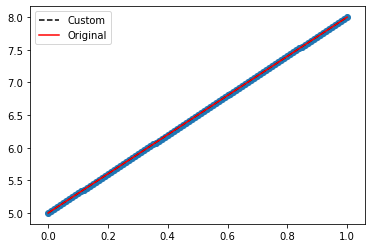

In [153]:
plt.scatter(x, y)

x2=np.linspace(0,1,101)

y1=mcus*x2 + bcus
y2=m*x2 + b

plt.plot(x2,y2, 'k--', label='Custom')
plt.plot(x2, y2, 'r', label='Original')
plt.legend()
plt.show()

# Discussion

The results are extremely similar. Between the two, there is a degree of error that is under .000001 which is extremely close. However, it is true that the np function matched the m value on the dot whereas the custom function did not. In addition, the custom function overshot m and undershot b. The built-in function was the opposite in undershooting m and hitting b on the dot.